# 451 Financial Engineering: Programming Assignment 1
## AAPL Return Prediction — v2 

Michael Dawson

---



## Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pyarrow
import polars as pl

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (log_loss, accuracy_score, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay,
                             ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score)

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

from scipy.stats import randint, uniform

## Retrieve Data — AAPL 



In [2]:


import yfinance as yf

start_date = '2010-01-01'
end_date   = '2026-04-16'

for sym, fname in [('AAPL', 'aapl_historical_data.csv'),
                   ('SPY',  'spy_historical_data.csv'),
                   ('QQQ',  'qqq_historical_data.csv'),
                   ('^VIX', 'vix_historical_data.csv'),
                   ('^TNX', 'tnx_historical_data.csv')]:
    print(f'pulling {sym}...')
    t = yf.Ticker(sym)
    h = t.history(start=start_date, end=end_date, auto_adjust=True)
    print(f'  rows: {len(h)}')
    h.to_csv(fname)

print('done')

pulling AAPL...
  rows: 4095
pulling SPY...
  rows: 4095
pulling QQQ...
  rows: 4095
pulling ^VIX...
  rows: 4095
pulling ^TNX...
  rows: 4093
done


## Feature Engineering — Step 1: Stationary AAPL Features



In [3]:
aapl = pl.read_csv('aapl_historical_data.csv', try_parse_dates=True)

# normalize Date so joins with exogenous series work cleanly
aapl = aapl.with_columns(pl.col('Date').cast(pl.Date))

# drop junk columns
drop_cols = [c for c in ['Dividends','Stock Splits','StockSplits','Capital Gains']
             if c in aapl.columns]
aapl = aapl.drop(drop_cols)

# core return (target source) 
aapl = aapl.with_columns(
    np.log(pl.col('Close') / pl.col('Close').shift()).alias('LogReturn')
)

# return lags (replaces CloseLag1/2/3) 
aapl = aapl.with_columns(pl.col('LogReturn').shift(1).alias('RetLag1'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(2).alias('RetLag2'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(3).alias('RetLag3'))

# percentage HML and OMC, plus lags
aapl = aapl.with_columns(((pl.col('High') - pl.col('Low')) / pl.col('Close')).alias('HMLpct'))
aapl = aapl.with_columns(((pl.col('Open') - pl.col('Close')) / pl.col('Close')).alias('OMCpct'))

aapl = aapl.with_columns(pl.col('HMLpct').shift(1).alias('HMLpctLag1'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(2).alias('HMLpctLag2'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(3).alias('HMLpctLag3'))

aapl = aapl.with_columns(pl.col('OMCpct').shift(1).alias('OMCpctLag1'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(2).alias('OMCpctLag2'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(3).alias('OMCpctLag3'))

# volume ratio vs 20-day average (stationary)
# use shifted volume so today's volume is never in a feature
aapl = aapl.with_columns(pl.col('Volume').shift(1).alias('Vol_t1'))
aapl = aapl.with_columns(
    pl.col('Vol_t1').rolling_mean(window_size=20).alias('Vol20')
)
aapl = aapl.with_columns((pl.col('Vol_t1') / pl.col('Vol20')).alias('VolRatioLag1'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(1).alias('VolRatioLag2'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(2).alias('VolRatioLag3'))

# return EMAs (replaces price EMAs) 
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=1, ignore_nulls=True).alias('RetEMA2'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=2, ignore_nulls=True).alias('RetEMA4'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=4, ignore_nulls=True).alias('RetEMA8'))

# rolling realized vol (new, stationary) 
aapl = aapl.with_columns(
    pl.col('RetLag1').rolling_std(window_size=20).alias('RetVol20')
)

# binary target
aapl = aapl.with_columns(
    pl.when(pl.col('LogReturn') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target')
)

print('aapl row count after v2 feature engineering:', aapl.height)
print('Date dtype:', aapl.schema['Date'])

aapl row count after v2 feature engineering: 4095
Date dtype: Date


## Feature Engineering 

- **SPY / QQQ**: lagged log return.
- **VIX**: lagged level (vol regime) and lagged change (regime shift).
- **^TNX**: lagged daily change in 10Y yield.

In [4]:
def load_and_prep(path, prefix):
    """Load an exogenous series, compute log return and level change, lag by 1 day."""
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close'])
    df = df.rename({'Close': f'{prefix}_Close'})
    df = df.with_columns(
        np.log(pl.col(f'{prefix}_Close') / pl.col(f'{prefix}_Close').shift()).alias(f'{prefix}_Ret')
    )
    df = df.with_columns(
        (pl.col(f'{prefix}_Close') - pl.col(f'{prefix}_Close').shift()).alias(f'{prefix}_Chg')
    )
    df = df.with_columns(pl.col(f'{prefix}_Ret').shift(1).alias(f'{prefix}_RetLag1'))
    df = df.with_columns(pl.col(f'{prefix}_Close').shift(1).alias(f'{prefix}_LvlLag1'))
    df = df.with_columns(pl.col(f'{prefix}_Chg').shift(1).alias(f'{prefix}_ChgLag1'))
    return df.select(['Date', f'{prefix}_RetLag1', f'{prefix}_LvlLag1', f'{prefix}_ChgLag1'])

spy = load_and_prep('spy_historical_data.csv', 'SPY')
qqq = load_and_prep('qqq_historical_data.csv', 'QQQ')
vix = load_and_prep('vix_historical_data.csv', 'VIX')
tnx = load_and_prep('tnx_historical_data.csv', 'TNX')

# keep only the most informative signal per series
spy = spy.select(['Date', 'SPY_RetLag1'])
qqq = qqq.select(['Date', 'QQQ_RetLag1'])
vix = vix.select(['Date', 'VIX_LvlLag1', 'VIX_ChgLag1'])
tnx = tnx.select(['Date', 'TNX_ChgLag1'])

# join on Date
aapl = aapl.join(spy, on='Date', how='left')
aapl = aapl.join(qqq, on='Date', how='left')
aapl = aapl.join(vix, on='Date', how='left')
aapl = aapl.join(tnx, on='Date', how='left')

# report null counts before dropping so we can see what's going on
print('null counts per column (before drop_nulls):')
for col in aapl.columns:
    n = aapl[col].null_count()
    if n > 0:
        print(f'  {col:20s} {n}')
print(f'total rows before drop_nulls: {aapl.height}')
print()

aapl = aapl.drop_nulls()

print(f'final row count: {aapl.height}')
print(f'date range: {aapl["Date"].min()} to {aapl["Date"].max()}')

null counts per column (before drop_nulls):
  LogReturn            1
  RetLag1              2
  RetLag2              3
  RetLag3              4
  HMLpctLag1           1
  HMLpctLag2           2
  HMLpctLag3           3
  OMCpctLag1           1
  OMCpctLag2           2
  OMCpctLag3           3
  Vol_t1               1
  Vol20                20
  VolRatioLag1         20
  VolRatioLag2         21
  VolRatioLag3         22
  RetEMA2              2
  RetEMA4              2
  RetEMA8              2
  RetVol20             21
  SPY_RetLag1          2
  QQQ_RetLag1          2
  VIX_LvlLag1          1
  VIX_ChgLag1          2
  TNX_ChgLag1          4
total rows before drop_nulls: 4095

final row count: 4071
date range: 2010-02-04 to 2026-04-15


## Train / Hold-Out Split

Same 85 / 10-row-gap / 15 discipline as v1. The hold-out is set aside before anything else.

In [5]:
HOLDOUT_FRAC = 0.15
GAP = 10

n_total   = int(aapl.height)
n_holdout = int(HOLDOUT_FRAC * n_total)
n_train   = n_total - n_holdout - GAP

print(f'n_total:   {n_total}')
print(f'n_holdout: {n_holdout}')
print(f'n_train:   {n_train}')

if n_train <= 0:
    raise ValueError('Not enough rows to split. Check upstream joins/drop_nulls.')

train   = aapl.slice(0, n_train)
holdout = aapl.slice(n_train + GAP, n_holdout)

print(f'train:   {train.height} rows   ({train["Date"].min()} to {train["Date"].max()})')
print(f'holdout: {holdout.height} rows   ({holdout["Date"].min()} to {holdout["Date"].max()})')

n_total:   4071
n_holdout: 610
n_train:   3451
train:   3451 rows   (2010-02-04 to 2023-10-23)
holdout: 610 rows   (2023-11-07 to 2026-04-15)


## Build Feature Matrix and Targets



In [6]:
feature_drop = ['Date','Open','High','Low','Close','Volume',
                'LogReturn','Target','HMLpct','OMCpct',
                'Vol_t1','Vol20']

X_train_df   = train.drop(feature_drop)
X_holdout_df = holdout.drop(feature_drop)

featureNames = X_train_df.columns
print('feature columns:')
for f in featureNames:
    print(' ', f)
print()

y_train   = np.array(train['Target'])
y_holdout = np.array(holdout['Target'])

print('class balance (train):  ', dict(zip(*np.unique(y_train, return_counts=True))))
print('class balance (holdout):', dict(zip(*np.unique(y_holdout, return_counts=True))))

feature columns:
  RetLag1
  RetLag2
  RetLag3
  HMLpctLag1
  HMLpctLag2
  HMLpctLag3
  OMCpctLag1
  OMCpctLag2
  OMCpctLag3
  VolRatioLag1
  VolRatioLag2
  VolRatioLag3
  RetEMA2
  RetEMA4
  RetEMA8
  RetVol20
  SPY_RetLag1
  QQQ_RetLag1
  VIX_LvlLag1
  VIX_ChgLag1
  TNX_ChgLag1

class balance (train):   {np.int32(0): np.int64(1628), np.int32(1): np.int64(1823)}
class balance (holdout): {np.int32(0): np.int64(282), np.int32(1): np.int64(328)}


## Scale Features

In [7]:
scaler = StandardScaler()
X_train   = scaler.fit_transform(np.array(X_train_df))
X_holdout = scaler.transform(np.array(X_holdout_df))

print('X_train shape:  ', X_train.shape)
print('X_holdout shape:', X_holdout.shape)

X_train shape:   (3451, 21)
X_holdout shape: (610, 21)


## Step 3: Model Comparison


In [8]:
tscv = TimeSeriesSplit(n_splits=5, gap=10)

# Logistic Regression 
logit_dist = {'C': uniform(0.001, 10.0)}
logit_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=2000, solver='lbfgs'),
    param_distributions=logit_dist,
    n_iter=20, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
logit_search.fit(X_train, y_train)
print(f'Logistic Regression  — best CV AUC: {logit_search.best_score_:.4f}   C={logit_search.best_params_["C"]:.3f}')

# Random Forest 
rf_dist = {
    'n_estimators':     randint(200, 800),
    'max_depth':        randint(3, 15),
    'min_samples_leaf': randint(1, 20),
    'max_features':     ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_dist,
    n_iter=40, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
rf_search.fit(X_train, y_train)
print(f'Random Forest        — best CV AUC: {rf_search.best_score_:.4f}')

#  XGBoost
xgb_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0.0, 1.0),
    'reg_lambda':       uniform(0.0, 1.0),
}
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            tree_method='hist', random_state=42),
    param_distributions=xgb_dist,
    n_iter=50, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost              — best CV AUC: {xgb_search.best_score_:.4f}')

Logistic Regression  — best CV AUC: 0.4878   C=9.700
Random Forest        — best CV AUC: 0.5126
XGBoost              — best CV AUC: 0.5119


## Final Hold-Out Evaluation — All Three Models

In [13]:
majority_class = int(np.bincount(y_train).argmax())
y_majority = np.full_like(y_holdout, majority_class)
majority_acc = accuracy_score(y_holdout, y_majority)

def evaluate(name, model):
    pred = model.predict(X_holdout)
    prob = model.predict_proba(X_holdout)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_holdout, pred),
        'AUC':      roc_auc_score(y_holdout, prob),
        'precision':precision_score(y_holdout, pred),
        'recall':   recall_score(y_holdout, pred),
        'f1':       f1_score(y_holdout, pred),
    }

results = [
    {'model': 'Majority class (baseline)', 'accuracy': majority_acc, 'AUC': 0.5,
     'precision': np.nan, 'recall': np.nan, 'f1': np.nan},
    evaluate('Logistic Regression', logit_search.best_estimator_),
    evaluate('Random Forest',       rf_search.best_estimator_),
    evaluate('XGBoost',             xgb_search.best_estimator_),
]


print('HOLD-OUT TEST SET RESULTS')
print(f'holdout period: {holdout["Date"].min()} to {holdout["Date"].max()}  ({len(y_holdout)} rows)')
print()
print(f'{"model":30s}  {"acc":>7s}  {"AUC":>7s}  {"prec":>7s}  {"rec":>7s}  {"f1":>7s}')
print('-' * 70)
for r in results:
    def fmt(x):
        return f'{x:7.4f}' if not (isinstance(x, float) and np.isnan(x)) else '   n/a '
    print(f'{r["model"]:30s}  {fmt(r["accuracy"])}  {fmt(r["AUC"])}  '
          f'{fmt(r["precision"])}  {fmt(r["recall"])}  {fmt(r["f1"])}')

HOLD-OUT TEST SET RESULTS
holdout period: 2023-11-07 to 2026-04-15  (610 rows)

model                               acc      AUC     prec      rec       f1
----------------------------------------------------------------------
Majority class (baseline)        0.5377   0.5000     n/a      n/a      n/a 
Logistic Regression              0.4967   0.4796   0.5210   0.7927   0.6288
Random Forest                    0.5049   0.4820   0.5323   0.6524   0.5863
XGBoost                          0.4967   0.4954   0.5279   0.6067   0.5645


## Diagnostics on the Best Holdout Model

In [10]:
model_results = [r for r in results if r['model'] != 'Majority class (baseline)']
best_name = max(model_results, key=lambda r: r['AUC'])['model']

model_lookup = {
    'Logistic Regression': logit_search.best_estimator_,
    'Random Forest':       rf_search.best_estimator_,
    'XGBoost':             xgb_search.best_estimator_,
}
best_model = model_lookup[best_name]
print('best holdout model:', best_name)

y_pred = best_model.predict(X_holdout)
y_prob = best_model.predict_proba(X_holdout)[:, 1]

print()
print('classification report on holdout:')
print(classification_report(y_holdout, y_pred))

best holdout model: XGBoost

classification report on holdout:
              precision    recall  f1-score   support

           0       0.45      0.37      0.40       282
           1       0.53      0.61      0.56       328

    accuracy                           0.50       610
   macro avg       0.49      0.49      0.48       610
weighted avg       0.49      0.50      0.49       610



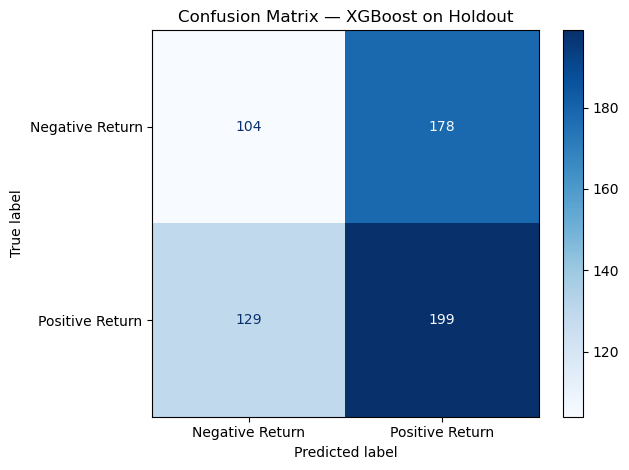

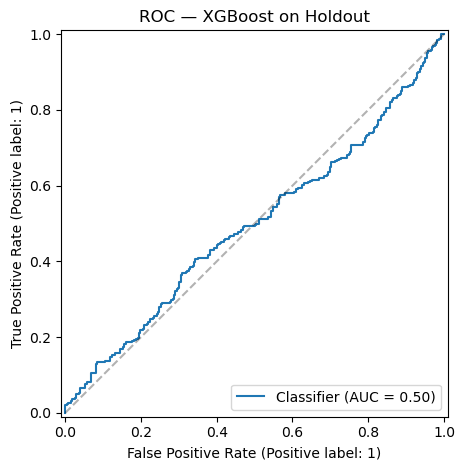

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_holdout, y_pred,
    display_labels=['Negative Return','Positive Return'],
    cmap=plt.cm.Blues,
)
plt.title(f'Confusion Matrix — {best_name} on Holdout')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_holdout, y_prob)
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.title(f'ROC — {best_name} on Holdout')
plt.tight_layout()
plt.show()

## Feature Importance — All Three Models

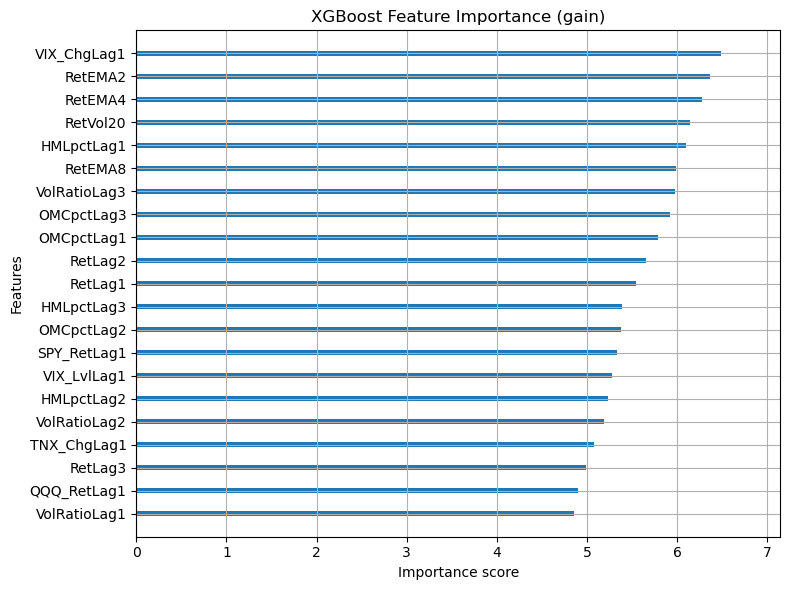

random forest feature importance:
  VIX_ChgLag1          0.0510
  HMLpctLag1           0.0506
  RetVol20             0.0495
  OMCpctLag2           0.0495
  RetEMA8              0.0494
  VolRatioLag3         0.0490
  TNX_ChgLag1          0.0479
  HMLpctLag2           0.0475
  RetLag3              0.0473
  VolRatioLag2         0.0472
  OMCpctLag3           0.0471
  VolRatioLag1         0.0471
  RetLag2              0.0470
  SPY_RetLag1          0.0469
  OMCpctLag1           0.0467
  RetEMA4              0.0467
  QQQ_RetLag1          0.0465
  VIX_LvlLag1          0.0465
  RetLag1              0.0461
  HMLpctLag3           0.0455
  RetEMA2              0.0449

logistic regression coefficients (sorted by absolute value):
  RetLag1              -0.2204
  QQQ_RetLag1          +0.1792
  RetEMA4              +0.1221
  SPY_RetLag1          -0.1106
  RetEMA2              +0.0749
  OMCpctLag2           +0.0730
  RetVol20             -0.0626
  TNX_ChgLag1          -0.0563
  RetLag3              -0.

In [12]:
# XGBoost feature importance
xgb_model = xgb_search.best_estimator_
booster = xgb_model.get_booster()
booster.feature_names = list(featureNames)

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(booster, ax=ax, importance_type='gain', show_values=False)
plt.title('XGBoost Feature Importance (gain)')
plt.tight_layout()
plt.show()

# Random forest feature importance
rf_model = rf_search.best_estimator_
rf_importances = sorted(zip(featureNames, rf_model.feature_importances_),
                         key=lambda x: x[1], reverse=True)
print('random forest feature importance:')
for name, imp in rf_importances:
    print(f'  {name:20s} {imp:.4f}')

# Logistic coefficients
logit_model = logit_search.best_estimator_
logit_coefs = sorted(zip(featureNames, logit_model.coef_[0]),
                     key=lambda x: abs(x[1]), reverse=True)
print()
print('logistic regression coefficients (sorted by absolute value):')
for name, c in logit_coefs:
    print(f'  {name:20s} {c:+.4f}')